<a href="https://colab.research.google.com/github/ElofssonLab/kb8029-book/blob/main/notebooks/day12-discussion-1.ipynb" style="display:inline-block;padding:10px 18px;background-color:#F9AB00;color:#000000;font-weight:bold;text-decoration:none;border-radius:6px;font-family:sans-serif;font-size:14px;">&#9654;&nbsp; Open in Google Colab</a>

# Day 12, Part 1 discussion — Do helices and sheets leave different fingerprints in a contact map?

The book page pooled eight structures and found that a contact makes its
neighbours 8-14 times more likely to be contacts too. Here we split by
fold class and compare the 3 × 3 neighbourhood of contacts in all-α
proteins with that in all-β proteins.

**Predict first:** in which direction (along the diagonal or across it)
should contacts continue for (a) two antiparallel β-strands, (b) two
parallel β-strands, (c) two packed helices?

In [1]:
import io, subprocess, sys, numpy as np, requests, matplotlib.pyplot as plt
from Bio.PDB import PDBParser
from Bio.PDB.Polypeptide import three_to_index, index_to_one
def chain_residues(text, chain_id=None):
    model = PDBParser(QUIET=True).get_structure("x", io.StringIO(text))[0]
    chain = model[chain_id] if chain_id else next(iter(model))
    res = [r for r in chain if r.id[0] == " " and "CA" in r]
    return res, "".join(index_to_one(three_to_index(r.get_resname())) for r in res)
def pdb_text(pid):
    return requests.get(f"https://files.rcsb.org/download/{pid}.pdb", timeout=60).text

def neighbourhood(pid, cid):
    res, _ = chain_residues(pdb_text(pid), cid)
    xyz = np.array([(r["CB"] if "CB" in r else r["CA"]).coord for r in res])
    C = np.linalg.norm(xyz[:, None] - xyz[None], axis=2) < 8
    L = len(C); acc = np.zeros((3, 3)); n = 0
    for a in range(1, L - 1):
        for b in range(a + 12, L - 1):          # long-ish range: skip local turns
            if C[a, b]:
                acc += C[a - 1:a + 2, b - 1:b + 2]; n += 1
    return acc, n

classes = {"all-alpha": [("4HHB", "B"), ("1MBN", "A"), ("2HMQ", "A")],
           "all-beta":  [("1TEN", "A"), ("2PTN", "A"), ("1TTG", "A")]}
result = {}
for name, prots in classes.items():
    acc, n = np.zeros((3, 3)), 0
    for pid, cid in prots:
        a, k = neighbourhood(pid, cid); acc += a; n += k
    result[name] = acc / n
    print(f"{name}: {n} contacts with |i-j| >= 12")
    print(np.round(result[name], 2))

all-alpha: 451 contacts with |i-j| >= 12
[[0.1  0.24 0.09]
 [0.24 1.   0.24]
 [0.08 0.23 0.1 ]]


all-beta: 887 contacts with |i-j| >= 12
[[0.27 0.48 0.4 ]
 [0.47 1.   0.46]
 [0.41 0.48 0.27]]


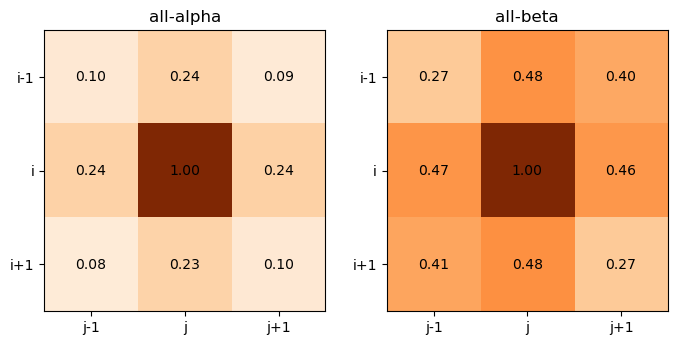

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(7, 3.4))
for ax, (name, P) in zip(axes, result.items()):
    ax.imshow(P, cmap="Oranges", vmin=0, vmax=1)
    for (r, c), v in np.ndenumerate(P):
        ax.text(c, r, f"{v:.2f}", ha="center", va="center")
    ax.set_title(name); ax.set_xticks([0, 1, 2]); ax.set_xticklabels(["j-1", "j", "j+1"])
    ax.set_yticks([0, 1, 2]); ax.set_yticklabels(["i-1", "i", "i+1"])
plt.tight_layout(); plt.show()

**Discuss:**

1. In the all-β proteins, which corner pair is more likely: (i−1, j+1) and
   (i+1, j−1) (the anti-diagonal), or (i−1, j−1) and (i+1, j+1) (the
   diagonal)? What does that say about how strands pair in these proteins?
2. How do the all-α neighbourhoods differ? (Hint: a helix turns every 3.6
   residues, so not every neighbouring residue faces the partner helix.)
3. PconsC2 and later CNNs learned such patterns from data. Could you use
   these probabilities directly to "clean up" a noisy coevolution map?